# 13 · Las figuras del paper

Los dashboards exploratorios del proyecto tienen **21 gráficas** solo para la comparación
v6 vs Parsimonious (`reporte_comparativo_v6_vs_parsimonious.html`). Eso sirve para explorar;
no sirve para publicar. Un paper de MSR lleva **6–7 figuras**, y cada una tiene que ganarse
el lugar respondiendo una RQ.

Este notebook genera **solo esas**, en formato vectorial listo para LaTeX.

## Corrección importante respecto de los dashboards existentes

`scripts/generate_comparison_plots.py` tiene dos modos permisivos y **ninguno es el que
este trabajo adoptó**:

| modo del script | actores | dirección | duplicados | ¿es el nuestro? |
|---|---|---|---|---|
| `legacy` (el que generó el HTML) | colapsa | **pierde** | **pierde** | ❌ son 3 reglas |
| `actor_only` | colapsa | conserva | conserva | ❌ falta la regla B |
| **este notebook** | colapsa | **funde bidireccionales** | conserva | ✅ 2 reglas |

La diferencia no es cosmética. Sobre la misma corrida de producción:

- estricto **57.87**
- `legacy` (3 reglas) **76.94**
- **2 reglas (correcto) 74.00**

Publicar el 76.94 sería reportar una relajación —colapsar duplicados— que el propio prompt
implementa a propósito. La definición completa y su justificación están en el notebook 03 §7.

## Decisiones de diseño

- **Paleta validada** con `validate_palette.js` (slots 1–3, all-pairs, modo claro):
  worst CVD ΔE 9.2, normal-vision 24.0. Todas las series llevan además **etiqueta directa o
  leyenda**, así la identidad nunca depende solo del color.
- **Salida vectorial** (PDF + SVG) a `reports/figuras_paper/`.
- **Un solo eje por gráfica.** Nada de doble eje.
- Marcas finas, grilla discreta, sin adornos.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from rich.console import Console

sys.path.append("..")
import scripts.core.graph_builder as _gb
from scripts.core.graph_builder import create_graph_from_cloudscape_json
from scripts.utils.evaluate_graphs import load_services_catalog

_gb.console = Console(quiet=True)

GT_DIR = Path("../data/cloudscape_gt")
ABL    = Path("../reports/ablation")
RUNS   = Path("../reports/runs")
OUT    = Path("../reports/figuras_paper"); OUT.mkdir(parents=True, exist_ok=True)

CATALOG = load_services_catalog(GT_DIR / "services.csv")
PISO = json.loads(Path("../reports/piso_ruido_panel30.json").read_text(encoding="utf-8"))
MDE = {k: v["mde_30"] for k, v in PISO["metricas"].items()}

# Paleta validada (skill dataviz, referencia). Slots 1-3, modo claro.
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"       # azul · naranja · aqua
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d8d8d4"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": INK2, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.facecolor": "white",
})


def guardar(fig, nombre: str) -> None:
    """Vectorial para LaTeX; PNG solo para mirarlo rapido."""
    for ext in ("pdf", "svg"):
        fig.savefig(OUT / f"{nombre}.{ext}")
    fig.savefig(OUT / f"{nombre}.png", dpi=200)
    print(f"  guardada · {nombre}.pdf / .svg / .png")


print(f"MDE n=30 — Edge {MDE['Edge F1']:.2f} pts · Service {MDE['Service F1']:.2f} pts")

MDE n=30 — Edge 3.29 pts · Service 1.76 pts


## El evaluador permisivo de 2 reglas

Se define acá, en el notebook que produce las figuras, para que ninguna cifra publicada
dependa de un script con un modo distinto por defecto.

In [2]:
def norm_actor(svc: str) -> str:
    """REGLA A — subtipos de actor colapsan. Usa capability, no solo el prefijo."""
    s = str(svc or "").strip()
    if not s or s == "?":
        return "Unknown"
    cap = CATALOG.get(s, {}).get("capability", "")
    if s.startswith("User") or cap == "User":
        return "User"
    if s.startswith("ThirdParty") or cap == "ThirdParty":
        return "ThirdParty"
    return s


def aristas_2reglas(G) -> Counter:
    """REGLA B — no dirigido. El dedup de bidireccionales se hace a nivel de PAR DE
    NODOS y ANTES de mapear a servicios: asi `a<->b` cuenta una vez, pero dos pares de
    nodos distintos que conectan los mismos dos servicios siguen contando dos."""
    pares_nodo = {tuple(sorted((u, v))) for u, v in G.edges()}
    return Counter(tuple(sorted((norm_actor(G.nodes[u].get("service", "")),
                                 norm_actor(G.nodes[v].get("service", "")))))
                   for u, v in pares_nodo)


def f1(inter, gen, gt):
    p = inter / gen if gen else 0.0
    r = inter / gt if gt else 0.0
    return 2 * p * r / (p + r) if p + r else 0.0


def evaluar_permisivo(G_gen, G_gt) -> tuple[float, float]:
    a = {norm_actor(G_gen.nodes[n].get("service", "")) for n in G_gen}
    b = {norm_actor(G_gt.nodes[n].get("service", "")) for n in G_gt}
    svc = f1(len(a & b), len(a), len(b))
    ge, te = aristas_2reglas(G_gen), aristas_2reglas(G_gt)
    edge = f1(sum((ge & te).values()), sum(ge.values()), sum(te.values()))
    return svc, edge


# Comprobacion contra el notebook 03: la definicion tiene que dar lo mismo.
ref = json.loads(Path("../reports/evaluacion_metricas_panel30.json").read_text(encoding="utf-8"))
run = json.loads((ABL / ref["corrida"] / "run.json").read_text(encoding="utf-8"))
perm = [evaluar_permisivo(create_graph_from_cloudscape_json(r["analysis"], video_id=r["video_id"]),
                          nx.read_graphml(GT_DIR / f"{r['video_id']}.graphml"))
        for r in run["results"] if r["status"] == "success"]
svc_p, edge_p = 100*np.mean([x[0] for x in perm]), 100*np.mean([x[1] for x in perm])

print(f"permisivo 2 reglas recalculado : svc {svc_p:.2f} · edge {edge_p:.2f}")
print(f"notebook 03 dice               : svc {ref['medias']['svc_permisiva']:.2f} · "
      f"edge {ref['medias']['edge_permisiva']:.2f}")
assert abs(edge_p - ref["medias"]["edge_permisiva"]) < 0.01
print("\nOK · misma definicion que el notebook 03.")

permisivo 2 reglas recalculado : svc 92.15 · edge 74.00
notebook 03 dice               : svc 92.15 · edge 74.00

OK · misma definicion que el notebook 03.


## Figura 1 · La asimetría (RQ1)

**Lo que dice:** identificar *qué servicios* hay se resuelve casi tan bien como un humano;
reconstruir *cómo se conectan* no. Cada punto es un video; la diagonal es "igual de bien en
las dos cosas".

Es la figura de apertura del paper: la brecha se ve sin leer un número.

  guardada · fig1_asimetria_servicios_vs_aristas.pdf / .svg / .png


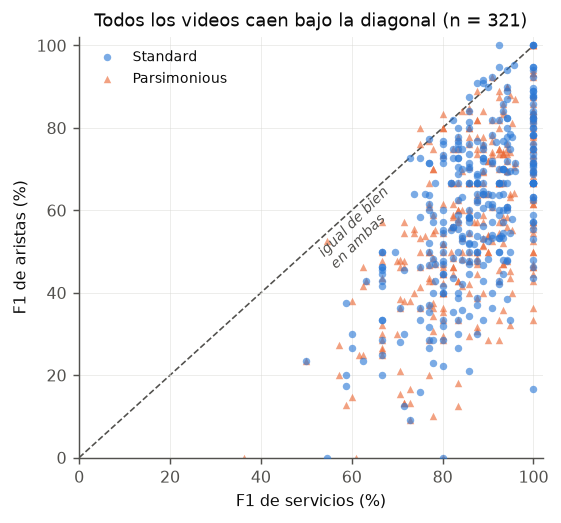

Standard     : svc 86.78 · edge 59.65 · brecha 27.1 pts
Parsimonious : svc 85.73 · edge 57.01 · brecha 28.7 pts


In [3]:
S = pd.read_csv(RUNS / "2026-08-20_standard_v6corrected_370v/results.csv")
P = pd.read_csv(RUNS / "2026-08-21_parsimonious_v9/results.csv")
D = S.merge(P, on="video_id", suffixes=("_s", "_p"))
D = D[(D.graph_usable_s == True) & (D.graph_usable_p == True)]

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.plot([0, 100], [0, 100], ls="--", c=INK2, lw=0.9, zorder=1)
ax.scatter(D.svc_f1_s, D.edge_f1_s, s=17, c=C1, alpha=.62, lw=0, zorder=3, label="Standard")
ax.scatter(D.svc_f1_p, D.edge_f1_p, s=17, c=C2, alpha=.62, lw=0,
           marker="^", zorder=2, label="Parsimonious")     # forma = 2do canal de identidad
ax.text(52, 46, "igual de bien\nen ambas", color=INK2, fontsize=7.5, style="italic", rotation=45)
ax.set_xlabel("F1 de servicios (%)"); ax.set_ylabel("F1 de aristas (%)")
ax.set_xlim(0, 102); ax.set_ylim(0, 102); ax.grid(alpha=.5, lw=.5)
ax.legend(loc="upper left", fontsize=8)
ax.set_title(f"Todos los videos caen bajo la diagonal (n = {len(D)})")
guardar(fig, "fig1_asimetria_servicios_vs_aristas"); plt.show()

print(f"Standard     : svc {D.svc_f1_s.mean():.2f} · edge {D.edge_f1_s.mean():.2f} "
      f"· brecha {D.svc_f1_s.mean()-D.edge_f1_s.mean():.1f} pts")
print(f"Parsimonious : svc {D.svc_f1_p.mean():.2f} · edge {D.edge_f1_p.mean():.2f} "
      f"· brecha {D.svc_f1_p.mean()-D.edge_f1_p.mean():.1f} pts")

## Figura 2 · El subdibujado (RQ1)

**Lo que dice:** el déficit es específico de la topología. Los nodos caen sobre la diagonal
—el sistema encuentra aproximadamente la cantidad correcta de servicios— y las aristas caen
sistemáticamente por debajo. Dos paneles, un solo eje cada uno.

  guardada · fig2_subdibujado.pdf / .svg / .png


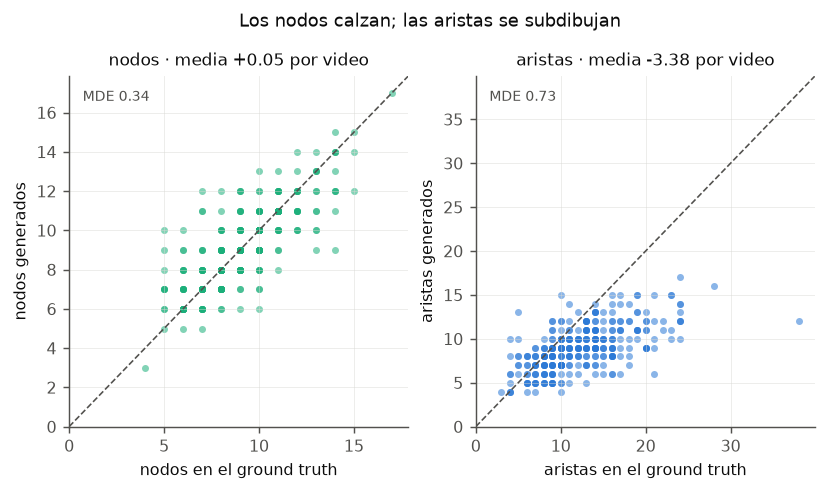

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.5), sharey=False)
for ax, (gen, gt_, tit, col) in zip(axes, [
        (D.gen_nodes_s, D.gt_nodes_s, "nodos", C3),
        (D.gen_edges_s, D.gt_edges_s, "aristas", C1)]):
    lim = max(gen.max(), gt_.max()) * 1.05
    ax.plot([0, lim], [0, lim], ls="--", c=INK2, lw=0.9)
    ax.scatter(gt_, gen, s=15, c=col, alpha=.55, lw=0)
    d = (gen - gt_).mean()
    ax.set_xlabel(f"{tit} en el ground truth"); ax.set_ylabel(f"{tit} generados")
    ax.set_title(f"{tit} · media {d:+.2f} por video", fontsize=9.5)
    ax.grid(alpha=.5, lw=.5); ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.text(.04, .93, f"MDE {MDE[tit + ' generados' if tit=='nodos' else 'aristas generadas']:.2f}",
            transform=ax.transAxes, fontsize=7.5, color=INK2)
fig.suptitle("Los nodos calzan; las aristas se subdibujan", y=1.02, fontsize=10)
guardar(fig, "fig2_subdibujado"); plt.show()

## Figura 3 · Invarianza de prompts (RQ2)

**Lo que dice:** las 11 variantes caben dentro de la banda de ruido. La banda gris es
±MDE alrededor de producción — no una barra de error de las variantes, sino **el umbral de
lo que este diseño puede detectar**.

  guardada · fig3_invarianza_de_prompts.pdf / .svg / .png


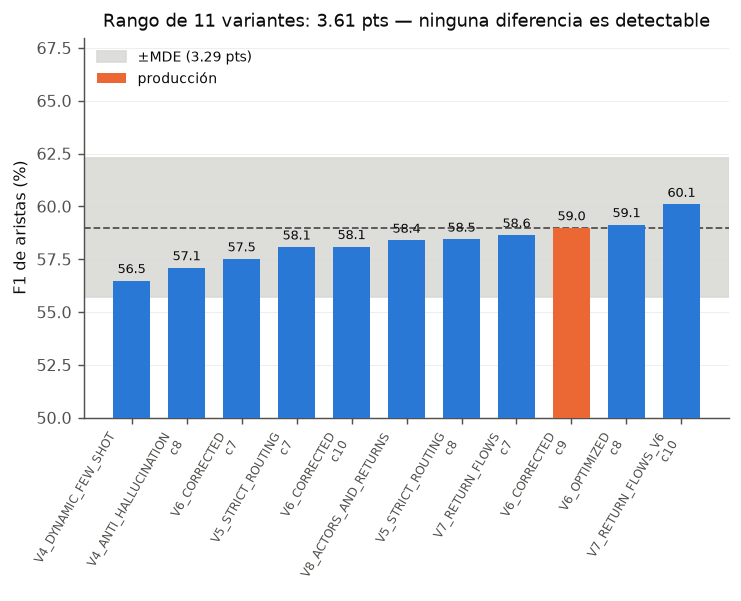

rango: 3.61 pts · MDE 3.29 pts


In [5]:
filas = []
for rj in sorted(ABL.glob("*_p30*/run.json")):
    d = json.loads(rj.read_text(encoding="utf-8"))
    if "stage2_prompt" not in d or d.get("oracle") or not d.get("transcript_enabled", True):
        continue
    sp = d["stage2_prompt"]
    nombre = sp["name"].replace("STAGE2_", "")
    if d.get("connection_evidence_enabled"):
        nombre += " +ev"
    filas.append({"variante": nombre, "celda": sp.get("source_cell"),
                  "sha": sp["sha256"][:8], "edge": d["metrics"]["edge_f1_mean"],
                  "es_prod": bool(sp.get("matches_production")) and not d.get("connection_evidence_enabled")})

V = pd.DataFrame(filas).drop_duplicates(subset="sha").sort_values("edge").reset_index(drop=True)
base = V.loc[V.es_prod, "edge"].mean()

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.axhspan(base - MDE["Edge F1"], base + MDE["Edge F1"], color=GRID, alpha=.85, zorder=1,
           label=f"±MDE ({MDE['Edge F1']:.2f} pts)")
ax.axhline(base, color=INK2, ls="--", lw=1, zorder=2)
colores = [C2 if e else C1 for e in V.es_prod]
ax.bar(range(len(V)), V.edge, color=colores, zorder=3, width=.66)
for i, (e, prod) in enumerate(zip(V.edge, V.es_prod)):
    ax.text(i, e + .35, f"{e:.1f}", ha="center", fontsize=7, color=INK)
ax.set_xticks(range(len(V)))
def etiqueta_celda(v):
    # `celda` viene float por el NaN de las variantes definidas en .py, no en el notebook.
    return "" if pd.isna(v) else f"c{int(v)}"


ax.set_xticklabels([f"{r.variante}\n{etiqueta_celda(r.celda)}" for r in V.itertuples()],
                   rotation=60, ha="right", fontsize=6.8)
ax.set_ylabel("F1 de aristas (%)")
ax.set_ylim(base - 9, base + 9)
rango = V.edge.max() - V.edge.min()
ax.set_title(f"Rango de {len(V)} variantes: {rango:.2f} pts — ninguna diferencia es detectable")
h, l = ax.get_legend_handles_labels()
h.append(plt.Rectangle((0, 0), 1, 1, fc=C2)); l.append("producción")
ax.legend(h, l, fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=.45, lw=.5)
guardar(fig, "fig3_invarianza_de_prompts"); plt.show()

print(f"rango: {V.edge.max()-V.edge.min():.2f} pts · MDE {MDE['Edge F1']:.2f} pts")

## Figura 4 · Los tres brazos (RQ3)

**Lo que dice:** el resultado central. Una transcripción humana de la pizarra **no** despega
del pipeline automático; darle la respuesta correcta sí. Las barras van etiquetadas con su
distancia al umbral en múltiplos de MDE, que es lo que convierte la figura en un argumento.

  guardada · fig4_tres_brazos_oraculo.pdf / .svg / .png


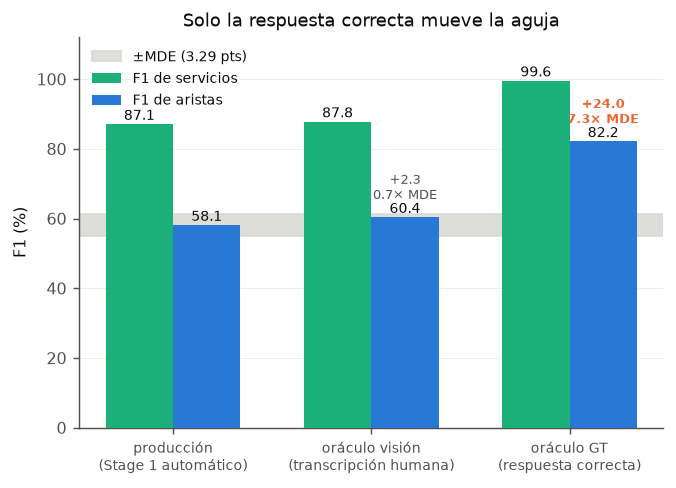

In [6]:
rq3 = json.loads(Path("../reports/rq3_oraculos.json").read_text(encoding="utf-8"))
b = rq3["brazos"]
orden = ["produccion", "A · vision", "B · oracle_gt"]
etiquetas = ["producción\n(Stage 1 automático)", "oráculo visión\n(transcripción humana)",
             "oráculo GT\n(respuesta correcta)"]
edges = [b[k]["edge_f1_mean"] for k in orden]
svcs  = [b[k]["service_f1_mean"] for k in orden]
base_e = edges[0]

fig, ax = plt.subplots(figsize=(5.8, 3.9))
ax.axhspan(base_e - MDE["Edge F1"], base_e + MDE["Edge F1"], color=GRID, alpha=.85,
           zorder=1, label=f"±MDE ({MDE['Edge F1']:.2f} pts)")
x = np.arange(3); w = .34
ax.bar(x - w/2, svcs,  w, color=C3, zorder=3, label="F1 de servicios")
ax.bar(x + w/2, edges, w, color=C1, zorder=3, label="F1 de aristas")
for i, (s, e) in enumerate(zip(svcs, edges)):
    ax.text(i - w/2, s + 1.2, f"{s:.1f}", ha="center", fontsize=7.5)
    ax.text(i + w/2, e + 1.2, f"{e:.1f}", ha="center", fontsize=7.5)
    if i:
        d = e - base_e
        ax.text(i + w/2, e + 5.2, f"{d:+.1f}\n{abs(d)/MDE['Edge F1']:.1f}× MDE",
                ha="center", fontsize=7, color=C2 if abs(d) > MDE["Edge F1"] else INK2,
                fontweight="bold" if abs(d) > MDE["Edge F1"] else "normal")
ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=8)
ax.set_ylabel("F1 (%)"); ax.set_ylim(0, 112)
ax.set_title("Solo la respuesta correcta mueve la aguja")
ax.legend(fontsize=8, loc="upper left"); ax.grid(axis="y", alpha=.45, lw=.5)
guardar(fig, "fig4_tres_brazos_oraculo"); plt.show()

## Figura 5 · Estricto vs permisivo de 2 reglas (protocolo)

**Lo que dice:** cuánto del error medido es de *convención* (subtipo de actor, sentido de la
flecha) y cuánto es de arquitectura. La barra apilada separa las dos cosas — y usa el
permisivo de **2 reglas**, no el de 3.

  guardada · fig5_estricto_vs_permisivo_2reglas.pdf / .svg / .png


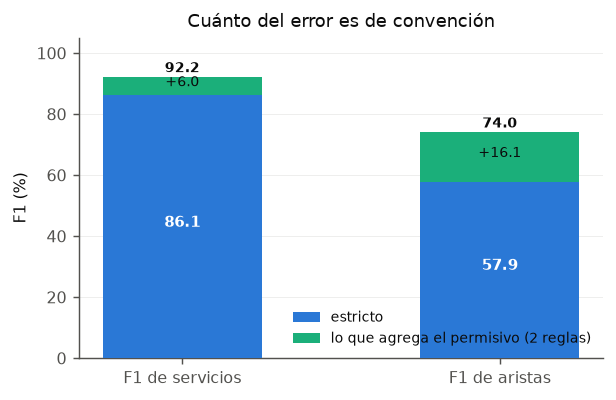

IMPORTANTE — el permisivo de 3 reglas daria edge 76.94 en vez de 74.00.
La diferencia es la regla que colapsa duplicados, que el prompt implementa a proposito.


In [7]:
est_svc = 100*np.mean([r["svc_f1"] for r in run["results"] if r["status"] == "success"])
est_edge = 100*np.mean([r["edge_f1"] for r in run["results"] if r["status"] == "success"])

fig, ax = plt.subplots(figsize=(5.2, 3.2))
metricas = ["F1 de servicios", "F1 de aristas"]
estricto = [est_svc, est_edge]
extra = [svc_p - est_svc, edge_p - est_edge]
x = np.arange(2)
ax.bar(x, estricto, .5, color=C1, zorder=3, label="estricto")
ax.bar(x, extra, .5, bottom=estricto, color=C3, zorder=3,
       label="lo que agrega el permisivo (2 reglas)")
for i, (e, ex) in enumerate(zip(estricto, extra)):
    ax.text(i, e/2, f"{e:.1f}", ha="center", color="white", fontweight="bold", fontsize=8.5)
    ax.text(i, e + ex/2, f"+{ex:.1f}", ha="center", color=INK, fontsize=8)
    ax.text(i, e + ex + 1.6, f"{e+ex:.1f}", ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(metricas); ax.set_ylabel("F1 (%)"); ax.set_ylim(0, 105)
ax.set_title("Cuánto del error es de convención")
ax.legend(fontsize=7.5, loc="lower right"); ax.grid(axis="y", alpha=.45, lw=.5)
guardar(fig, "fig5_estricto_vs_permisivo_2reglas"); plt.show()

print(f"IMPORTANTE — el permisivo de 3 reglas daria edge 76.94 en vez de {edge_p:.2f}.")
print("La diferencia es la regla que colapsa duplicados, que el prompt implementa a proposito.")

## Figura 6 · La tarea downstream (RQ5)

**Lo que dice:** sustituir un corpus anotado a mano por uno extraído automáticamente
preserva el 94.8 % de las clasificaciones, y el error es **direccional** — el pipeline
sub-clasifica. Matriz de confusión, que muestra las dos cosas a la vez.

  guardada · fig6_tarea_downstream.pdf / .svg / .png


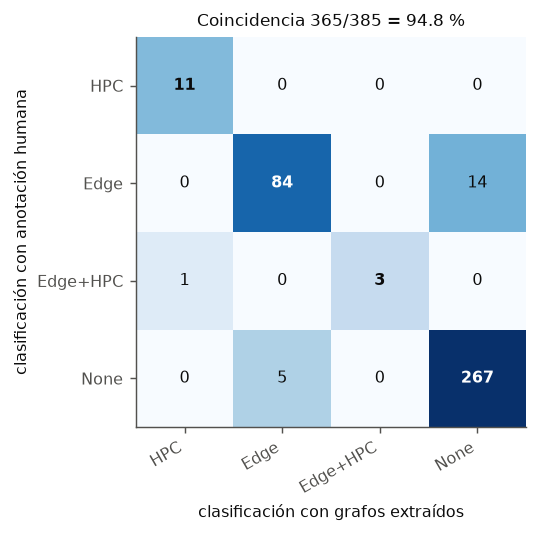

Direcciones del desacuerdo: {'Edge->None': 14, 'None->Edge': 5, 'Edge+HPC->HPC': 1}


In [8]:
rq5 = json.loads(Path("../reports/rq5_tarea_downstream.json").read_text(encoding="utf-8"))
ORDEN = ["HPC", "Edge", "Edge+HPC", "None"]

sys.path.insert(0, "../scripts/santillan_abad")
from _paths import find_pkg
PKG = find_pkg()

def cargar(c):
    df = pd.read_csv(PKG / c / "arquitecturas_clasificadas_con_metadata.csv")
    df["tipo"] = df["tipo_arquitectura"].fillna("None")
    return df

m = cargar("run_gt385")[["architecture", "tipo"]].merge(
    cargar("run_extracted385")[["architecture", "tipo"]], on="architecture",
    suffixes=("_gt", "_ex"))
mat = pd.crosstab(m.tipo_gt, m.tipo_ex).reindex(index=ORDEN, columns=ORDEN, fill_value=0)

fig, ax = plt.subplots(figsize=(4.4, 3.9))
# Secuencial de un solo tono (azul), light->dark. Nunca arcoiris.
im = ax.imshow(np.log1p(mat.values), cmap="Blues", vmin=0)
for i in range(4):
    for j in range(4):
        v = mat.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=9,
                fontweight="bold" if i == j else "normal",
                color="white" if np.log1p(v) > np.log1p(mat.values.max())*.55 else INK)
ax.set_xticks(range(4)); ax.set_xticklabels(ORDEN, rotation=30, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(ORDEN)
ax.set_xlabel("clasificación con grafos extraídos")
ax.set_ylabel("clasificación con anotación humana")
acc = rq5["propagacion_de_error"]["tasa_coincidencia"]
ax.set_title(f"Coincidencia {int(acc*385)}/385 = {100*acc:.1f} %", fontsize=9.5)
ax.grid(False)
guardar(fig, "fig6_tarea_downstream"); plt.show()

print("Direcciones del desacuerdo:", rq5["propagacion_de_error"]["direcciones_desacuerdo"])

## Inventario final

In [9]:
figs = sorted({p.stem for p in OUT.glob("*.pdf")})
inv = pd.DataFrame([{
    "figura": f,
    "RQ": {"fig1": "RQ1", "fig2": "RQ1", "fig3": "RQ2",
           "fig4": "RQ3", "fig5": "protocolo", "fig6": "RQ5"}.get(f[:4], "—"),
    "pdf": (OUT / f"{f}.pdf").exists(),
    "svg": (OUT / f"{f}.svg").exists(),
} for f in figs])
display(inv)
print(f"\n{len(figs)} figuras en {OUT}")
print("\nEn LaTeX:  \\includegraphics[width=\\columnwidth]{figuras_paper/fig1_...pdf}")

,figura,RQ,pdf,svg
0,fig1_asimetria_servicios_vs_aristas,RQ1,True,True
1,fig2_subdibujado,RQ1,True,True
2,fig3_invarianza_de_prompts,RQ2,True,True
3,fig4_tres_brazos_oraculo,RQ3,True,True
4,fig5_estricto_vs_permisivo_2reglas,protocolo,True,True
5,fig6_tarea_downstream,RQ5,True,True



6 figuras en ../reports/figuras_paper

En LaTeX:  \includegraphics[width=\columnwidth]{figuras_paper/fig1_...pdf}


## Lo que se dejó afuera, y por qué

De las 21 gráficas del dashboard, **15 no entran**:

| descartada | por qué |
|---|---|
| radar multimétrica (×2) | el radar distorsiona magnitudes según el orden de los ejes; una tabla dice lo mismo sin engañar |
| rendimiento por video (sample 25) | una muestra arbitraria de 25 de 321 no sostiene ninguna afirmación |
| top servicios alucinados/faltantes (×4) | cola larga con conteos de 2–3; es exploración, no resultado |
| rendimiento por capability (×2) | n por celda demasiado chico para leer diferencias |
| "salud del pipeline" (×2) | mezcla métricas de escalas distintas en un mismo panel |
| distribución de rangos F1 (×2) | el boxplot de la fig. 1 ya lo cubre mejor |
| top conexiones alucinadas/faltantes (×2) | el notebook 07 lo analiza con causas, que es lo publicable |
| volumen y composición de errores (×2) | absorbido por las figs. 2 y 5 |

**Criterio:** una figura entra si **responde una RQ** y si su afirmación **sobrevive al piso
de ruido**. Las que muestran diferencias por debajo del MDE se sacaron por definición — son
justamente lo que este trabajo demuestra que no se puede leer.